In [18]:
import os 
os.environ["JAX_PLATFORMS"] = 'cpu'
from utils_activations import *
from utils import makefolder


rcpsize = 20
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

In [24]:
import matplotlib.pyplot as plt
import numpy as np

n_files = 21
model_name = 'gemma12b'
precision = 32
data_var = 'syn'
global_center_flag = 1
min_token_length = 3
n_tokens = min_token_length 
k_recall = 3
avg_tokens = 0

if model_name == 'gemma12b':
  load_data_f = collect_data_hf
else:
  load_data_f = collect_data

syntax_labels = np.loadtxt(syn_group_ids_path).astype(int)  # (n_samples,)
syn_ids_with_sem = jnp.array(np.loadtxt(syn_ids_with_sem_path,dtype=int),dtype=jnp.int32) # filtering syn_data to have their semantic centroid in space A 
syntax_labels = syntax_labels[syn_ids_with_sem]

input_path_A = input_paths['english'][model_name]['matching']['0'][data_var]
input_path_B = input_path_A.replace('second', 'third').replace('0', '1')

all_activations_A = load_data_f(input_path_A, 
                                min_token_length, 
                                n_files,
                                model_name,
                                avg_tokens,
                                )
all_activations_B = load_data_f(input_path_B, 
                                min_token_length, 
                                n_files,
                                model_name,
                                avg_tokens,
                                )

layers = list(range(1, depths[model_name] + 1))
layer_vals = reduce_list_half_preserve_extremes(layers)

recalls_0 = np.empty(len(layer_vals))
recalls_sem = np.empty_like(recalls_0)
recalls_syn = np.empty_like(recalls_0)
recalls_sem_perm = np.empty_like(recalls_0)
recalls_syn_perm = np.empty_like(recalls_0)

layer_id = -1
for layer in tqdm(layer_vals,desc='layer_vals'):
  layer_id += 1
  act_A, syn_centroids_A, sem_centroids_A, global_center_A = preprocessing_syn_data(
      model_name=model_name,
      all_activations=all_activations_A, 
      global_center_flag=global_center_flag,
      space_index='A',
      layer=layer, 
      avg_tokens=avg_tokens,
      n_tokens=n_tokens,
      min_token_length=min_token_length,
      syn_ids_with_sem=syn_ids_with_sem,
  )
  act_B, _, _, global_center_B = preprocessing_syn_data(
      model_name=model_name,
      all_activations=all_activations_B, 
      global_center_flag=global_center_flag,
      space_index='B',
      layer=layer, 
      avg_tokens=avg_tokens,
      n_tokens=n_tokens,
      min_token_length=min_token_length,
      syn_ids_with_sem=syn_ids_with_sem,
  )
  idx = jnp.arange(act_A.shape[0], dtype=jnp.int32)
  key_idx = jax.random.PRNGKey(42)
  permuted_idx = jax.random.permutation(key_idx, act_A.shape[0])  # perm of [0..N-1]

  syn_centroids_A = batched_remove_centroid_projections(syn_centroids_A,idx,sem_centroids_A)

  ### X retriving syntax-twin
  cos_matrix_0 = all_cosine_similarities(act_A, act_B)
  r_0 = recall_at_k_syn(cos_matrix_0, k_recall, syntax_labels)
  recalls_0[layer_id] = float(r_0)
  
  ### semantic ablation
  act_A_sem = batched_remove_centroid_projections(act_A,idx,sem_centroids_A)
  cos_matrix_sem = all_cosine_similarities(act_A_sem, act_B)
  r_sem = recall_at_k_syn(cos_matrix_sem, k_recall, syntax_labels)
  recalls_sem[layer_id] = float(r_sem)

  ### syntax ablation
  act_A_syn = batched_remove_centroid_projections(act_A,idx,syn_centroids_A)
  cos_matrix_syn = all_cosine_similarities(act_A_syn, act_B)
  r_syn = recall_at_k_syn(cos_matrix_syn, k_recall, syntax_labels)
  recalls_syn[layer_id] = float(r_syn)

  ### random controls
  act_A_sem_perm = batched_remove_centroid_projections(act_A,permuted_idx,sem_centroids_A)
  cos_matrix_sem_perm = all_cosine_similarities(act_A_sem_perm, act_B)
  r_sem_perm = recall_at_k_syn(cos_matrix_sem_perm, k_recall, syntax_labels)
  recalls_sem_perm[layer_id] = float(r_sem_perm)

  act_A_syn_perm = batched_remove_centroid_projections(act_A,permuted_idx,syn_centroids_A)
  cos_matrix_syn_perm = all_cosine_similarities(act_A_syn_perm, act_B)
  r_syn_perm = recall_at_k_syn(cos_matrix_syn_perm, k_recall, syntax_labels)
  recalls_syn_perm[layer_id] = float(r_syn_perm)

### Saving
resultsfolder = makefolder(base='results/recall/syn/',
                        create_folder=True,
                        model_name=model_name,
                        avg_tokens=avg_tokens,
                        min_token_length=min_token_length,
                        global_center_flag=global_center_flag,
                        k=k_recall,
                        )
# Prepare data to save
layer_vals_arr = np.array(layer_vals)
rel_depths = layer_vals_arr / depths[model_name]

save_path = os.path.join(resultsfolder, f"recall_k{k_recall}.npz")

np.savez(
    save_path,
    layer_vals=layer_vals_arr,
    rel_depths=rel_depths,
    recalls_0=recalls_0,
    recalls_sem=recalls_sem,
    recalls_syn=recalls_syn,
    recalls_sem_perm=recalls_sem_perm,
    recalls_syn_perm=recalls_syn_perm,
)


Reading 21 chunks from: /home/acevedo/syn-sem/datasets/activations/syn/second/gemma12b/matching/english/0/


Loading: 100%|██████████| 21/21 [00:53<00:00,  2.57s/it]



Loaded model: gemma12b (dtype=torch.bfloat16)
all_hidden_states["layer_0"].shape=torch.Size([2098, 3, 3840])
importing took 0.9203924576441447 m
Reading 21 chunks from: /home/acevedo/syn-sem/datasets/activations/syn/third/gemma12b/matching/english/1/


Loading: 100%|██████████| 21/21 [00:53<00:00,  2.53s/it]



Loaded model: gemma12b (dtype=torch.bfloat16)
all_hidden_states["layer_0"].shape=torch.Size([2098, 3, 3840])
importing took 0.9131444533665974 m


layer_vals:   0%|          | 0/24 [00:00<?, ?it/s]

act.shape=(1584, 11520)
expanded_syn_centroids.shape=(1584, 11520)
sem_centroids.shape=(1584, 11520)
act.shape=(1584, 11520)
expanded_syn_centroids.shape=(1584, 11520)


layer_vals: 100%|██████████| 24/24 [02:54<00:00,  7.25s/it]


In [25]:
import os
import numpy as np
from utils import makefolder,depths
import matplotlib.pyplot as plt

n_files = 21
model_name = 'deepseek'
precision = 32
data_var = 'syn'
global_center_flag = 1
min_token_length = 3
n_tokens = min_token_length 
k_recall = 3
avg_tokens = 0

resultsfolder = makefolder(base='results/recall/syn/',
                        model_name=model_name,
                        avg_tokens=avg_tokens,
                        min_token_length=min_token_length,
                        global_center_flag=global_center_flag,
                        k=k_recall,
                        )

results_path = os.path.join(resultsfolder, f"recall_k{k_recall}.npz")

data = np.load(results_path)

layer_vals      = data["layer_vals"]
rel_depths      = data["rel_depths"]
recalls_0       = data["recalls_0"]
recalls_sem     = data["recalls_sem"]
recalls_syn     = data["recalls_syn"]
recalls_sem_perm = data["recalls_sem_perm"]
recalls_syn_perm = data["recalls_syn_perm"]


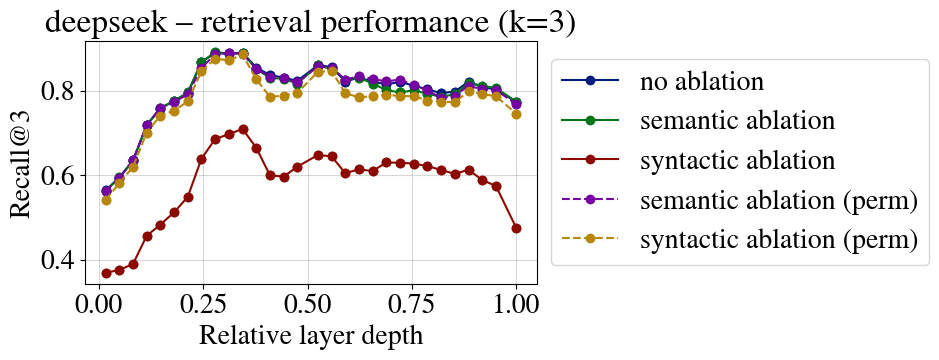

In [26]:
# Convert to numpy just to be safe
layer_vals_arr = np.array(layer_vals)
rel_depths = layer_vals_arr / depths[model_name]

# Plot recalls vs relative depth
fig, ax = plt.subplots(figsize=(7, 4))

plt.plot(rel_depths, recalls_0, marker='o', label='no ablation')
plt.plot(rel_depths, recalls_sem, marker='o', label='semantic ablation')
plt.plot(rel_depths, recalls_syn, marker='o', label='syntactic ablation')
plt.plot(rel_depths, recalls_sem_perm, marker='o', linestyle='--',
          label='semantic ablation (perm)')
plt.plot(rel_depths, recalls_syn_perm, marker='o', linestyle='--',
          label='syntactic ablation (perm)')

# Optional: scatter on top for a bit more emphasis (your alpha prefs)
plt.scatter(rel_depths, recalls_0, alpha=0.9)
plt.scatter(rel_depths, recalls_sem, alpha=0.9)
plt.scatter(rel_depths, recalls_syn, alpha=0.9)
plt.scatter(rel_depths, recalls_sem_perm, alpha=0.9)
plt.scatter(rel_depths, recalls_syn_perm, alpha=0.9)

plt.xlabel('Relative layer depth')
plt.ylabel(f'Recall@{k_recall}')
plt.title(f'{model_name} – retrieval performance (k={k_recall})')
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig_path = os.path.join(resultsfolder, f"recall_k{k_recall}.png")
plt.savefig(fig_path, dpi=300)
plt.show()
plt.close()

In [27]:
normalization_flag = 1
shuffled_controls = [0,1]
C = 1000
for shuffled_control_id,shuffled_control in enumerate(shuffled_controls):
    resultsfolder = makefolder(base='./results/syntax_classification/',
                           model_name=model_name,
                           avg_tokens=0,
                           normalization_flag=normalization_flag,
                           shuffled_control=shuffled_control,
                           C=C,
                           )

    results = np.load(resultsfolder+'results.npz')

    # syn_layer_indices   = results['layer_indices']
    if shuffled_control == 0:
      syn_accs_A = results['accs_A']
      syn_ablated_syn_accs_A = results['syn_ablated_accs_A']
      sem_ablated_syn_accs_A = results['sem_ablated_accs_A']
    elif shuffled_control == 1:
      syn_ablated_syn_accs_A_perm = results['syn_ablated_accs_A']
      sem_ablated_syn_accs_A_perm = results['sem_ablated_accs_A']

# syntax classification
# mapping rows so that the labels match the retrieval experiment:
#   no ablation              -> syn_accs_A
#   semantic ablation        -> sem_ablated_syn_accs_A
#   syntactic ablation       -> syn_ablated_syn_accs_A
#   semantic ablation (perm) -> sem_ablated_syn_accs_A_perm
#   syntactic ablation (perm)-> syn_ablated_syn_accs_A_perm
best_accs = [
    syn_accs_A.max(),
    sem_ablated_syn_accs_A.max(),
    syn_ablated_syn_accs_A.max(),
    sem_ablated_syn_accs_A_perm.max(),
    syn_ablated_syn_accs_A_perm.max(),
]

In [28]:
import os
import numpy as np

k_recall = 3  # recall@k shown in the table

def fmt_num(x):
    return f"{float(x):.2f}"

def style_val(x, max_val, min_val):
    s = fmt_num(x)
    # small tolerance to avoid float/rounding issues
    if np.isclose(x, max_val, atol=0.005, rtol=0):
        return r"\underline{" + s + "}"   # biggest
    elif np.isclose(x, min_val, atol=0.005, rtol=0):
        return r"\textbf{" + s + "}"      # smallest
    else:
        return s

row_labels = [
    r"\shortstack{baseline\\(no ablation)}",
    r"\shortstack{semantic\\ablation}",
    r"\shortstack{syntactic\\ablation}",
    r"\shortstack{semantic\\ablation\\(random)}",
    r"\shortstack{syntactic\\ablation\\(random)}",
]

# best_accs must already be in memory from your syntax-classification loading code
# best_accs = [...]

# --- load retrieval results for BOTH experiments ---
# We'll store:
#   - best_twin_recalls : from results/recall/syn/   (syntax-twin-recall)
#   - best_p_recalls    : from results/recall/sem/   (P-recall)

best_recalls_by_var = {}

for var in ["syn", "sem"]:
    recall_resultsfolder = makefolder(
        base=f"results/recall/{var}/",
        create_folder=False,
        model_name=model_name,
        avg_tokens=0 if var == "syn" else 1,
        min_token_length=min_token_length,
        global_center_flag=global_center_flag,
        k=k_recall,
    )

    recall_npz_path = os.path.join(recall_resultsfolder, f"recall_k{k_recall}.npz")
    recall_data = np.load(recall_npz_path)

    recalls_0        = recall_data["recalls_0"]
    recalls_sem      = recall_data["recalls_sem"]
    recalls_syn      = recall_data["recalls_syn"]
    recalls_sem_perm = recall_data["recalls_sem_perm"]
    recalls_syn_perm = recall_data["recalls_syn_perm"]

    best_recalls_by_var[var] = [
        recalls_0.max(),         # no ablation
        recalls_sem.max(),       # semantic ablation
        recalls_syn.max(),       # syntactic ablation
        recalls_sem_perm.max(),  # semantic ablation (perm)
        recalls_syn_perm.max(),  # syntactic ablation (perm)
    ]

best_twin_recalls = best_recalls_by_var["syn"]
best_p_recalls    = best_recalls_by_var["sem"]

# --- column-wise max/min for styling ---
max_acc,  min_acc  = float(np.max(best_accs)),        float(np.min(best_accs))
max_twin, min_twin = float(np.max(best_twin_recalls)), float(np.min(best_twin_recalls))
max_p,    min_p    = float(np.max(best_p_recalls)),    float(np.min(best_p_recalls))

# --- build LaTeX table ---
lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{2pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")
lines.append(r"\begin{tabular}{|c|c|c|c|}")

lines.append(r"\hline")
lines.append(
    r" & \shortstack{Best\\syn-acc} & "
    rf"\shortstack{{Best syn-\\recall@{k_recall}}} & "
    rf"\shortstack{{Best sem-\\recall@{k_recall}}} \\"
)
lines.append(r"\hline")

for label, a_val, t_val, p_val in zip(row_labels, best_accs, best_twin_recalls, best_p_recalls):
    lines.append(
        f"{label} & "
        f"{style_val(a_val, max_acc,  min_acc)} & "
        f"{style_val(t_val, max_twin, min_twin)} & "
        f"{style_val(p_val, max_p,    min_p)} \\\\\\hline"
    )

lines.append(r"\end{tabular}")
lines.append(r"\label{tab:probes_main}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)

# --- save ---
tablefolder = "results/table/"
os.makedirs(tablefolder, exist_ok=True)
table_path = os.path.join(tablefolder, f"{model_name}_k{k_recall}.txt")
with open(table_path, "w") as f:
    f.write(latex_table)

print(f"Saved LaTeX table to {table_path}")


Saved LaTeX table to results/table/deepseek_k3.txt
